# Task 1: Analysing Data with Spark SQL 
# 1. Dataset Source and Structure
# 1.1 Load Dataset and Preview Directory


This section confirms the dataset folder structure (month partitions and per-force CSV files). 

It establishes the temporal coverage and validates that the input matches the intended scope before any Spark processing.

In [1]:
from pathlib import Path

ROOT = Path("/kaggle/input/t1-police-data")
if not ROOT.exists():
    raise FileNotFoundError(f"Root path not found: {ROOT}")

months = sorted([p for p in ROOT.iterdir() if p.is_dir()])
print(f"Months detected: {len(months)}")
print([p.name for p in months[:6]])

# Sample files in the first two month folders
for p in months[:2]:
    sample = sorted([f.name for f in p.glob("*.csv")])[:6]
    print(f"\nMonth folder: {p.name}")
    for s in sample:
        print("  ", s)

Months detected: 25
['2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04']

Month folder: 2023-11
   2023-11-essex-street.csv
   2023-11-leicestershire-street.csv
   2023-11-metropolitan-street.csv
   2023-11-norfolk-street.csv
   2023-11-northern-ireland-street.csv
   2023-11-west-midlands-street.csv

Month folder: 2023-12
   2023-12-essex-street.csv
   2023-12-leicestershire-street.csv
   2023-12-metropolitan-street.csv
   2023-12-norfolk-street.csv
   2023-12-northern-ireland-street.csv
   2023-12-west-midlands-street.csv



# 1.2 Data Preparation

This section builds a clean, analysis-ready dataset in Spark by loading all files, normalising schema and deriving month and force fields for consistent grouping in Spark SQL.

In [2]:
from pyspark.sql import SparkSession, functions as F

DATA_PATH = str(ROOT / "*" / "*.csv")

spark = SparkSession.builder.appName("CSIP5203_Task1_CrimeSQL").getOrCreate()

df_raw = (
    spark.read
         .option("header", True)
         .option("inferSchema", True)
         .csv(DATA_PATH)
         .withColumn("file_path", F.input_file_name())
)

print("Loaded rows:", df_raw.count())
df_raw.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/18 00:51:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded rows: 4059565
root
 |-- Crime ID: string (nullable = true)
 |-- Month: timestamp (nullable = true)
 |-- Reported by: string (nullable = true)
 |-- Falls within: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA code: string (nullable = true)
 |-- LSOA name: string (nullable = true)
 |-- Crime type: string (nullable = true)
 |-- Last outcome category: string (nullable = true)
 |-- Context: string (nullable = true)
 |-- file_path: string (nullable = false)



This cell renames raw Police data headers into snake_case and casts longitude/latitude into numeric types. 

This reduces schema ambiguity and ensures spatial filters/aggregations behave correctly.

In [3]:
RENAME_MAP = {
    "Crime ID": "crime_id",
    "Month": "month_str",
    "Reported by": "reported_by",
    "Falls within": "falls_within",
    "Crime type": "crime_type",
    "Last outcome category": "outcome",
    "LSOA code": "lsoa_code",
    "LSOA name": "lsoa_name",
    "Location": "location",
    "Longitude": "lon",
    "Latitude": "lat"
}

df_norm = df_raw
for old, new in RENAME_MAP.items():
    if old in df_norm.columns:
        df_norm = df_norm.withColumnRenamed(old, new)

df_norm = (
    df_norm
        .withColumn("lon", F.col("lon").cast("double"))
        .withColumn("lat", F.col("lat").cast("double"))
)

df_norm.select(
    "crime_id", "month_str", "reported_by",
    "falls_within", "crime_type", "outcome",
    "lon", "lat"
).show(5, truncate=False)


+----------------------------------------------------------------+-------------------+---------------------------+---------------------------+----------------------------+---------------------------+---------+---------+
|crime_id                                                        |month_str          |reported_by                |falls_within               |crime_type                  |outcome                    |lon      |lat      |
+----------------------------------------------------------------+-------------------+---------------------------+---------------------------+----------------------------+---------------------------+---------+---------+
|94cce8effdcd939bce021aacd07b5d33a8389265fde201c18e651fbf849f78b5|2025-07-01 00:00:00|Metropolitan Police Service|Metropolitan Police Service|Violence and sexual offences|Unable to prosecute suspect|-0.250117|50.837908|
|4ba6d869dcd0556337c067118d34af3597d38adfa11fb8f847e09ab359d91f08|2025-07-01 00:00:00|Metropolitan Police Service|Metrop

This cell extracts year and month_num from the CSV file path and creates year_month. 
It defines force using an existing dataset field and registers a SQL view for Spark SQL analysis.

In [4]:

YEAR_RE = r".*/(\d{4})-\d{2}-[a-z-]+-street\.csv$"
MON_RE  = r".*/\d{4}-(\d{2})-[a-z-]+-street\.csv$"

df_prep = (
    df_norm
        .withColumn("year", F.regexp_extract("file_path", YEAR_RE, 1))
        .withColumn("month_num", F.regexp_extract("file_path", MON_RE, 1))
        .withColumn("year_month", F.concat_ws("-", "year", "month_num"))
        .withColumn("force", F.col("falls_within"))
)

df_prep.createOrReplaceTempView("crimes")

df_prep.select(
    "file_path", "year", "month_num",
    "year_month", "force"
).show(6, truncate=False)


+---------------------------------------------------------------------------+----+---------+----------+---------------------------+
|file_path                                                                  |year|month_num|year_month|force                      |
+---------------------------------------------------------------------------+----+---------+----------+---------------------------+
|file:///kaggle/input/t1-police-data/2025-07/2025-07-metropolitan-street.csv|2025|07       |2025-07   |Metropolitan Police Service|
|file:///kaggle/input/t1-police-data/2025-07/2025-07-metropolitan-street.csv|2025|07       |2025-07   |Metropolitan Police Service|
|file:///kaggle/input/t1-police-data/2025-07/2025-07-metropolitan-street.csv|2025|07       |2025-07   |Metropolitan Police Service|
|file:///kaggle/input/t1-police-data/2025-07/2025-07-metropolitan-street.csv|2025|07       |2025-07   |Metropolitan Police Service|
|file:///kaggle/input/t1-police-data/2025-07/2025-07-metropolitan-street.csv

# 2. Data Cleaning 

In [5]:

null_profile_df = spark.createDataFrame([
    (c,
     df_prep.filter(F.col(c).isNull()).count(),
     round(100 * df_prep.filter(F.col(c).isNull()).count() / df_prep.count(), 2)
    )
    for c in df_prep.columns
], ["column_name", "null_count", "null_pct"])

null_profile_df.orderBy(F.desc("null_pct")).show(truncate=False)


+------------+----------+--------+
|column_name |null_count|null_pct|
+------------+----------+--------+
|Context     |4059565   |100.0   |
|outcome     |901905    |22.22   |
|crime_id    |704479    |17.35   |
|lsoa_name   |305787    |7.53    |
|lsoa_code   |305787    |7.53    |
|lon         |19701     |0.49    |
|lat         |19701     |0.49    |
|file_path   |0         |0.0     |
|crime_type  |0         |0.0     |
|year        |0         |0.0     |
|month_str   |0         |0.0     |
|month_num   |0         |0.0     |
|location    |0         |0.0     |
|year_month  |0         |0.0     |
|reported_by |0         |0.0     |
|force       |0         |0.0     |
|falls_within|0         |0.0     |
+------------+----------+--------+



The missing values in crime_id and outcome are handled in next sections.

In [6]:
# Drop Context column (100% missing, no analytical value)
df_clean = df_prep.drop("Context")

This cell summarises dataset integrity using Spark SQL: 

* total rows,
* number of forces,
* months covered and
* null rates for key fields (crime_type, outcome, coordinates).


In [7]:
integrity_df = spark.sql("""
WITH base AS (
  SELECT
    COUNT(*) AS rows_total,
    COUNT(DISTINCT force) AS forces,
    COUNT(DISTINCT year_month) AS distinct_yyyymm,
    SUM(CASE WHEN crime_type IS NULL THEN 1 ELSE 0 END) AS null_crime_type,
    SUM(CASE WHEN outcome IS NULL THEN 1 ELSE 0 END) AS null_outcome,
    SUM(CASE WHEN lat IS NULL OR lon IS NULL THEN 1 ELSE 0 END) AS null_coords
  FROM crimes
)
SELECT
  rows_total,
  forces,
  distinct_yyyymm,
  null_crime_type,
  ROUND(100.0 * null_crime_type / rows_total, 2) AS pct_null_crime_type,
  null_outcome,
  ROUND(100.0 * null_outcome / rows_total, 2) AS pct_null_outcome,
  null_coords,
  ROUND(100.0 * null_coords / rows_total, 2) AS pct_null_coords
FROM base
""")

integrity_df.show(truncate=False)

+----------+------+---------------+---------------+-------------------+------------+----------------+-----------+---------------+
|rows_total|forces|distinct_yyyymm|null_crime_type|pct_null_crime_type|null_outcome|pct_null_outcome|null_coords|pct_null_coords|
+----------+------+---------------+---------------+-------------------+------------+----------------+-----------+---------------+
|4059565   |6     |25             |0              |0.00               |901905      |22.22           |19701      |0.49           |
+----------+------+---------------+---------------+-------------------+------------+----------------+-----------+---------------+



This cell groups by crime_type and quantifies the percentage of missing crime_id per category. 

This establishes whether missingness is structural rather than random.

In [8]:
crime_type_validation_df = spark.sql("""
SELECT
  crime_type,
  COUNT(*) AS total_records,
  SUM(CASE WHEN crime_id IS NULL THEN 1 ELSE 0 END) AS null_crime_id_records,
  ROUND(
    100.0 * SUM(CASE WHEN crime_id IS NULL THEN 1 ELSE 0 END) / COUNT(*),
    2
  ) AS pct_null_crime_id
FROM crimes
GROUP BY crime_type
ORDER BY pct_null_crime_id DESC
""")

crime_type_validation_df.show(truncate=False)


+----------------------------+-------------+---------------------+-----------------+
|crime_type                  |total_records|null_crime_id_records|pct_null_crime_id|
+----------------------------+-------------+---------------------+-----------------+
|Anti-social behaviour       |704479       |704479               |100.00           |
|Bicycle theft               |42222        |0                    |0.00             |
|Public order                |213194       |0                    |0.00             |
|Drugs                       |149099       |0                    |0.00             |
|Other crime                 |62173        |0                    |0.00             |
|Robbery                     |89835        |0                    |0.00             |
|Criminal damage and arson   |255321       |0                    |0.00             |
|Theft from the person       |203728       |0                    |0.00             |
|Shoplifting                 |312005       |0                    

This cell creates crimes_final with 

(i) outcome_clean to label missing outcomes explicitly and

(ii) is_asb to flag records with missing crime_id for interpretation, not removal.

In [9]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW crimes_final AS
SELECT
  *,
  CASE
    WHEN outcome IS NULL THEN 'Outcome not recorded'
    ELSE outcome
  END AS outcome_clean,
  CASE
    WHEN crime_id IS NULL THEN 1
    ELSE 0
  END AS is_asb
FROM crimes
""")

DataFrame[]

In [10]:
print("Outcome categories after cleaning:")
spark.sql("""
SELECT
  outcome_clean,
  COUNT(*) AS records
FROM crimes_final
GROUP BY outcome_clean
ORDER BY records DESC
""").show(truncate=False)


Outcome categories after cleaning:


+---------------------------------------------------+-------+
|outcome_clean                                      |records|
+---------------------------------------------------+-------+
|Investigation complete; no suspect identified      |1503467|
|Unable to prosecute suspect                        |1005131|
|Outcome not recorded                               |901905 |
|Under investigation                                |163479 |
|Status update unavailable                          |145909 |
|Court result unavailable                           |109316 |
|Awaiting court outcome                             |76359  |
|Local resolution                                   |74074  |
|Action to be taken by another organisation         |38692  |
|Offender given a caution                           |15776  |
|Formal action is not in the public interest        |10606  |
|Further action is not in the public interest       |4731   |
|Offender given penalty notice                      |4608   |
|Further

In [11]:
print("ASB flag distribution:")
spark.sql("""
SELECT
  is_asb,
  COUNT(*) AS records
FROM crimes_final
GROUP BY is_asb
""").show(truncate=False)


ASB flag distribution:


+------+-------+
|is_asb|records|
+------+-------+
|1     |704479 |
|0     |3355086|
+------+-------+



# 3. Trends

This cell summarises per-force coverage (months, crime types, outcomes). It checks whether forces have comparable temporal scope and category richness before cross-force comparisons.

In [12]:
coverage_df = spark.sql("""
SELECT
  force,
  COUNT(DISTINCT year_month) AS months_covered,
  COUNT(DISTINCT crime_type) AS n_crime_types,
  COUNT(DISTINCT outcome) AS n_outcomes
FROM crimes_final
GROUP BY force
ORDER BY force
""")

coverage_df.show(truncate=False)

+----------------------------------+--------------+-------------+----------+
|force                             |months_covered|n_crime_types|n_outcomes|
+----------------------------------+--------------+-------------+----------+
|Essex Police                      |25            |14           |14        |
|Leicestershire Police             |25            |14           |14        |
|Metropolitan Police Service       |25            |14           |15        |
|Norfolk Constabulary              |25            |14           |14        |
|Police Service of Northern Ireland|25            |14           |0         |
|West Midlands Police              |25            |14           |13        |
+----------------------------------+--------------+-------------+----------+



This cell generates Spark SQL aggregates for monthly totals (for time-series plots) and yearly totals (for year-on-year comparison). It provides the core trend metrics.

In [13]:

# Monthly totals per force
monthly_df = spark.sql("""
SELECT
  force,
  year,
  month_num,
  COUNT(*) AS month_total
FROM crimes_final
GROUP BY force, year, month_num
ORDER BY force, year, month_num
""")

# Yearly totals per force 
yearly_df = spark.sql("""
SELECT
  year,
  force,
  COUNT(*) AS total_crimes
FROM crimes_final
GROUP BY year, force
ORDER BY year, total_crimes DESC
""")

monthly_df.show(10, truncate=False)
yearly_df.show(10, truncate=False)

+------------+----+---------+-----------+
|force       |year|month_num|month_total|
+------------+----+---------+-----------+
|Essex Police|2023|11       |13292      |
|Essex Police|2023|12       |13110      |
|Essex Police|2024|01       |13148      |
|Essex Police|2024|02       |12722      |
|Essex Police|2024|03       |14092      |
|Essex Police|2024|04       |12875      |
|Essex Police|2024|05       |12872      |
|Essex Police|2024|06       |13020      |
|Essex Police|2024|07       |14471      |
|Essex Police|2024|08       |14125      |
+------------+----+---------+-----------+
only showing top 10 rows



+----+----------------------------------+------------+
|year|force                             |total_crimes|
+----+----------------------------------+------------+
|2023|Metropolitan Police Service       |190199      |
|2023|West Midlands Police              |56327       |
|2023|Essex Police                      |26402       |
|2023|Police Service of Northern Ireland|21908       |
|2023|Leicestershire Police             |16925       |
|2023|Norfolk Constabulary              |10380       |
|2024|Metropolitan Police Service       |1139329     |
|2024|West Midlands Police              |342166      |
|2024|Essex Police                      |158403      |
|2024|Police Service of Northern Ireland|141256      |
+----+----------------------------------+------------+
only showing top 10 rows



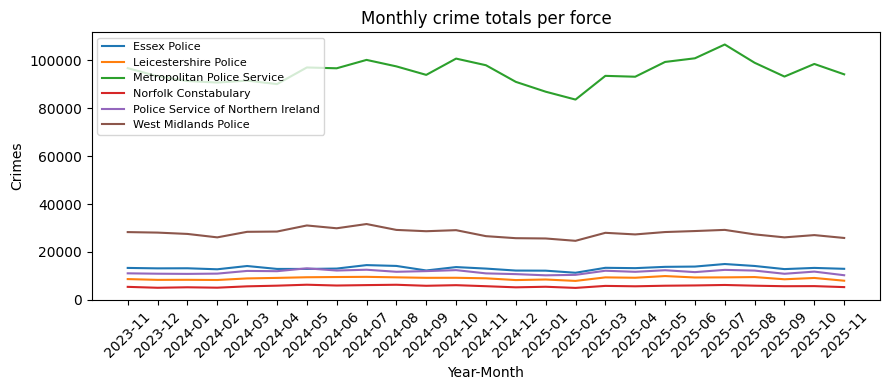

<Figure size 800x400 with 0 Axes>

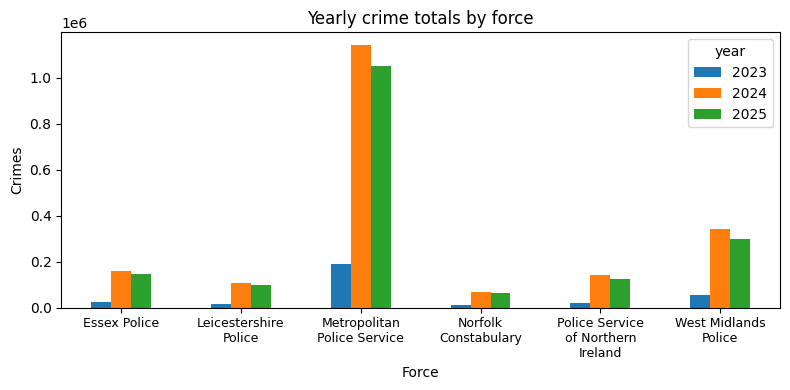

In [14]:

# Convert to pandas for quick plotting
import matplotlib.pyplot as plt
import textwrap

pdf_month = monthly_df.toPandas()
pdf_year  = yearly_df.toPandas()

#  Monthly totals per force
plt.figure(figsize=(9,4))
for f in sorted(pdf_month['force'].unique()):
    d = pdf_month[pdf_month['force']==f].copy()
    # Compose an ordered x-axis using year-month for display
    d['ym'] = d['year'].astype(str) + "-" + d['month_num'].astype(str).str.zfill(2)
    plt.plot(d['ym'], d['month_total'], label=f)
plt.xticks(rotation=45)
plt.title("Monthly crime totals per force")
plt.xlabel("Year-Month"); plt.ylabel("Crimes"); plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Yearly totals by force

plt.figure(figsize=(8,4))
pivot_y = pdf_year.pivot(index='force', columns='year', values='total_crimes').fillna(0)
ax = pivot_y.plot(kind='bar', figsize=(8,4))

wrapped = [textwrap.fill(t.get_text(), width=14) for t in ax.get_xticklabels()]
ax.set_xticklabels(wrapped, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=9)  

plt.title("Yearly crime totals by force")
plt.xlabel("Force"); plt.ylabel("Crimes")
plt.tight_layout()
plt.show()

In [15]:

# Rank forces by yearly total using a window function
ranked_df = spark.sql("""
WITH yearly AS (
  SELECT year, force, COUNT(*) AS total_crimes
  FROM crimes_final
  GROUP BY year, force
),
ranked AS (
  SELECT
    year,
    force,
    total_crimes,
    ROW_NUMBER() OVER (PARTITION BY year ORDER BY total_crimes DESC) AS rank_in_year
  FROM yearly
)
SELECT * FROM ranked
ORDER BY year, rank_in_year
""")

# Compute yearly shares
share_df = spark.sql("""
WITH yearly AS (
  SELECT year, force, COUNT(*) AS total_crimes
  FROM crimes_final
  GROUP BY year, force
),
sum_y AS (
  SELECT year, SUM(total_crimes) AS year_total FROM yearly GROUP BY year
)
SELECT
  y.year,
  y.force,
  y.total_crimes,
  ROUND(100.0 * y.total_crimes / s.year_total, 2) AS pct_share
FROM yearly y
JOIN sum_y s ON y.year = s.year
ORDER BY y.year, y.total_crimes DESC
""")

ranked_df.show(truncate=False)
share_df.show(truncate=False)


+----+----------------------------------+------------+------------+
|year|force                             |total_crimes|rank_in_year|
+----+----------------------------------+------------+------------+
|2023|Metropolitan Police Service       |190199      |1           |
|2023|West Midlands Police              |56327       |2           |
|2023|Essex Police                      |26402       |3           |
|2023|Police Service of Northern Ireland|21908       |4           |
|2023|Leicestershire Police             |16925       |5           |
|2023|Norfolk Constabulary              |10380       |6           |
|2024|Metropolitan Police Service       |1139329     |1           |
|2024|West Midlands Police              |342166      |2           |
|2024|Essex Police                      |158403      |3           |
|2024|Police Service of Northern Ireland|141256      |4           |
|2024|Leicestershire Police             |107902      |5           |
|2024|Norfolk Constabulary              |69028  

+----+----------------------------------+------------+---------+
|year|force                             |total_crimes|pct_share|
+----+----------------------------------+------------+---------+
|2023|Metropolitan Police Service       |190199      |59.04    |
|2023|West Midlands Police              |56327       |17.49    |
|2023|Essex Police                      |26402       |8.20     |
|2023|Police Service of Northern Ireland|21908       |6.80     |
|2023|Leicestershire Police             |16925       |5.25     |
|2023|Norfolk Constabulary              |10380       |3.22     |
|2024|Metropolitan Police Service       |1139329     |58.19    |
|2024|West Midlands Police              |342166      |17.47    |
|2024|Essex Police                      |158403      |8.09     |
|2024|Police Service of Northern Ireland|141256      |7.21     |
|2024|Leicestershire Police             |107902      |5.51     |
|2024|Norfolk Constabulary              |69028       |3.53     |
|2025|Metropolitan Police

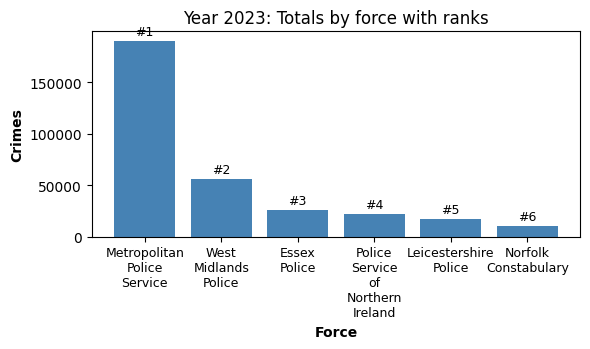

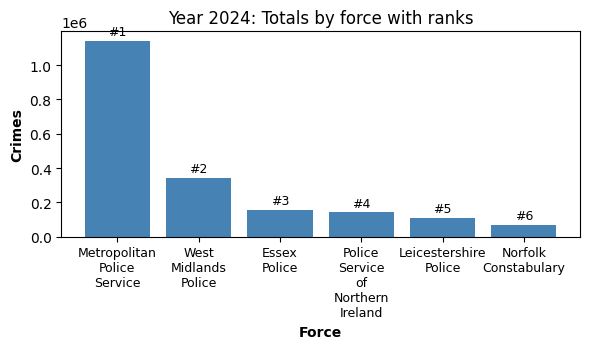

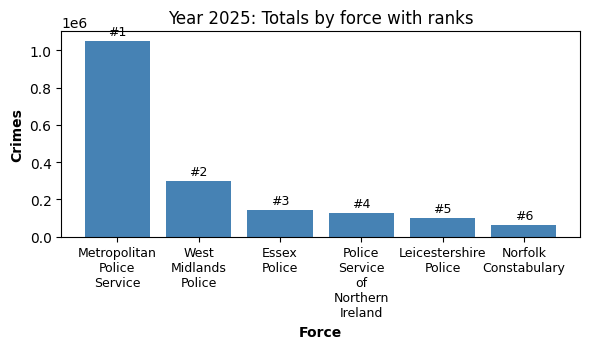

In [16]:
import matplotlib.pyplot as plt

pdf_rank = ranked_df.toPandas()

for y in sorted(pdf_rank['year'].unique()):
    d = pdf_rank[pdf_rank['year']==y].sort_values('rank_in_year').reset_index(drop=True)

    plt.figure(figsize=(6, 3.6))
    ax = plt.gca()

    # Bars
    ax.bar(range(len(d)), d['total_crimes'], color='steelblue')

    # Rank labels
    y_off = d['total_crimes'].max() * 0.015
    for i, r in d.iterrows():
        ax.text(i, r['total_crimes'] + y_off, f"#{int(r['rank_in_year'])}",
                ha='center', va='bottom', fontsize=9)

    # Wrapped x labels (no warnings)
    labels = ['\n'.join(f.split()) for f in d['force']]
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(labels, ha='center', fontsize=9)

    # Labels + title
    plt.title(f"Year {y}: Totals by force with ranks")
    plt.xlabel("Force", fontweight='bold')
    plt.ylabel("Crimes", fontweight='bold')

    plt.tight_layout()
    plt.show()

In [17]:

# Within-force shares by crime type 
type_share_df = spark.sql("""
WITH totals AS (
  SELECT force, COUNT(*) AS force_total
  FROM crimes_final
  GROUP BY force
)
SELECT
  c.force,
  c.crime_type,
  COUNT(*) AS ct,
  ROUND(100.0 * COUNT(*) / CAST(t.force_total AS DOUBLE), 2) AS pct_within_force
FROM crimes_final c
JOIN totals t ON c.force = t.force
WHERE c.crime_type IS NOT NULL
GROUP BY c.force, c.crime_type, t.force_total
ORDER BY c.force, pct_within_force DESC
""")

# Top-3 crime types per force 
type_top_df = spark.sql("""
WITH ranked AS (
  SELECT
    force,
    crime_type,
    COUNT(*) AS ct,
    ROW_NUMBER() OVER (PARTITION BY force ORDER BY COUNT(*) DESC) AS rn
  FROM crimes_final
  WHERE crime_type IS NOT NULL
  GROUP BY force, crime_type
)
SELECT force, crime_type, ct
FROM ranked
WHERE rn <= 3
ORDER BY force, ct DESC
""")

type_share_df.show(10, truncate=False)
type_top_df.show(50, truncate=False)


+------------+----------------------------+------+----------------+
|force       |crime_type                  |ct    |pct_within_force|
+------------+----------------------------+------+----------------+
|Essex Police|Violence and sexual offences|131875|39.91           |
|Essex Police|Anti-social behaviour       |29876 |9.04            |
|Essex Police|Shoplifting                 |27972 |8.47            |
|Essex Police|Criminal damage and arson   |26465 |8.01            |
|Essex Police|Vehicle crime               |24889 |7.53            |
|Essex Police|Public order                |23394 |7.08            |
|Essex Police|Other theft                 |22707 |6.87            |
|Essex Police|Burglary                    |12466 |3.77            |
|Essex Police|Drugs                       |12166 |3.68            |
|Essex Police|Other crime                 |7442  |2.25            |
+------------+----------------------------+------+----------------+
only showing top 10 rows



+----------------------------------+----------------------------+------+
|force                             |crime_type                  |ct    |
+----------------------------------+----------------------------+------+
|Essex Police                      |Violence and sexual offences|131875|
|Essex Police                      |Anti-social behaviour       |29876 |
|Essex Police                      |Shoplifting                 |27972 |
|Leicestershire Police             |Violence and sexual offences|80636 |
|Leicestershire Police             |Anti-social behaviour       |26039 |
|Leicestershire Police             |Public order                |20763 |
|Metropolitan Police Service       |Violence and sexual offences|546701|
|Metropolitan Police Service       |Anti-social behaviour       |484684|
|Metropolitan Police Service       |Other theft                 |225067|
|Norfolk Constabulary              |Violence and sexual offences|58526 |
|Norfolk Constabulary              |Anti-social beh

In [18]:
# Spatial-only subset
spark.sql("""
CREATE OR REPLACE TEMP VIEW crimes_spatial AS
SELECT *
FROM crimes_final
WHERE lat IS NOT NULL
  AND lon IS NOT NULL
""")


DataFrame[]

In [19]:
# A10) Outcome distribution and LSOA / grid summaries

# Outcome distribution by force 
outcome_df = spark.sql("""
SELECT force, outcome_clean, COUNT(*) AS ct
FROM crimes_final
GROUP BY force, outcome_clean
ORDER BY force, ct DESC
""")

# Top LSOAs per force (for Table 2.3)
lsoa_top_df = spark.sql("""
WITH ranked AS (
  SELECT
    force,
    lsoa_code,
    lsoa_name,
    COUNT(*) AS ct,
    ROW_NUMBER() OVER (PARTITION BY force ORDER BY COUNT(*) DESC) AS rn
  FROM crimes_spatial
  WHERE lsoa_code IS NOT NULL
  GROUP BY force, lsoa_code, lsoa_name
)
SELECT force, lsoa_code, lsoa_name, ct
FROM ranked
WHERE rn <= 10
ORDER BY force, ct DESC
""")

# Grid intensity using rounded coordinates (for Figure 2.6)
grid_df = spark.sql("""
SELECT
  force,
  ROUND(lat, 3) AS lat3,
  ROUND(lon, 3) AS lon3,
  COUNT(*) AS ct
FROM crimes_spatial
WHERE lat IS NOT NULL AND lon IS NOT NULL
GROUP BY force, ROUND(lat, 3), ROUND(lon, 3)
ORDER BY force, ct DESC
""")

outcome_df.show(10, truncate=False)
lsoa_top_df.show(20, truncate=False)
grid_df.show(10, truncate=False)


+------------+---------------------------------------------+------+
|force       |outcome_clean                                |ct    |
+------------+---------------------------------------------+------+
|Essex Police|Unable to prosecute suspect                  |113980|
|Essex Police|Investigation complete; no suspect identified|111448|
|Essex Police|Outcome not recorded                         |29876 |
|Essex Police|Court result unavailable                     |16742 |
|Essex Police|Under investigation                          |11769 |
|Essex Police|Local resolution                             |11197 |
|Essex Police|Action to be taken by another organisation   |9506  |
|Essex Police|Status update unavailable                    |9317  |
|Essex Police|Awaiting court outcome                       |8515  |
|Essex Police|Formal action is not in the public interest  |3823  |
+------------+---------------------------------------------+------+
only showing top 10 rows



+---------------------+---------+--------------------------+-----+
|force                |lsoa_code|lsoa_name                 |ct   |
+---------------------+---------+--------------------------+-----+
|Essex Police         |E01015852|Southend-on-Sea 015B      |4259 |
|Essex Police         |E01021318|Basildon 015C             |3239 |
|Essex Police         |E01035158|Colchester 007G           |3197 |
|Essex Police         |E01035178|Uttlesford 006E           |2778 |
|Essex Police         |E01022025|Tendring 016B             |2738 |
|Essex Police         |E01033140|Chelmsford 022D           |2357 |
|Essex Police         |E01034370|Thurrock 022C             |2295 |
|Essex Police         |E01034090|Chelmsford 022C           |2285 |
|Essex Police         |E01015841|Southend-on-Sea 014C      |2265 |
|Essex Police         |E01034092|Chelmsford 023B           |2234 |
|Leicestershire Police|E01034022|Leicester 041E            |10858|
|Leicestershire Police|E01032873|Leicester 041D            |32

+------------+------+-----+----+
|force       |lat3  |lon3 |ct  |
+------------+------+-----+----+
|Essex Police|51.895|0.268|1658|
|Essex Police|51.544|0.711|1100|
|Essex Police|51.487|0.283|1064|
|Essex Police|51.731|0.475|870 |
|Essex Police|51.912|0.901|735 |
|Essex Police|51.479|0.32 |722 |
|Essex Police|51.736|0.477|649 |
|Essex Police|51.545|0.684|642 |
|Essex Police|51.768|0.096|623 |
|Essex Police|51.558|0.451|570 |
+------------+------+-----+----+
only showing top 10 rows



In [20]:
import pandas as pd

pdf_out = outcome_df.toPandas()
pivot_out = (pdf_out
             .pivot_table(index="force", columns="outcome_clean", values="ct", aggfunc="sum")
             .fillna(0))


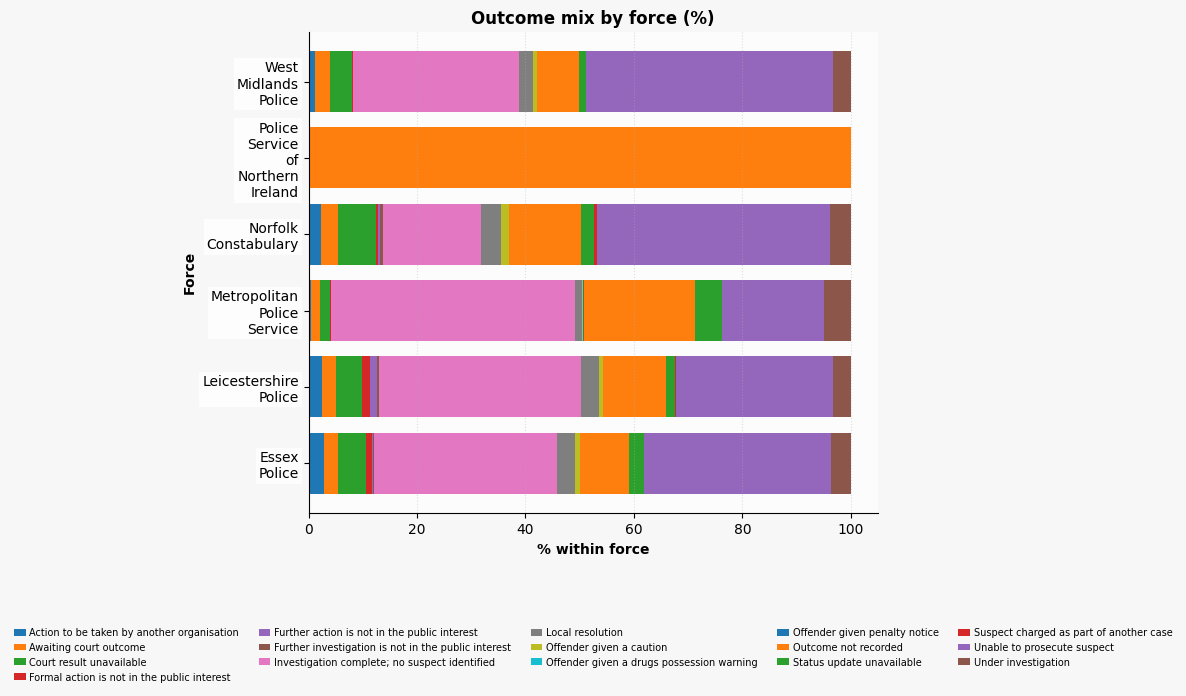

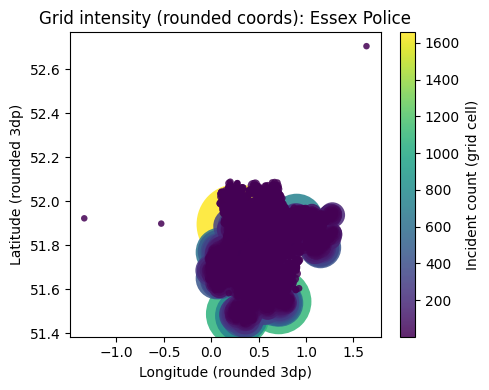

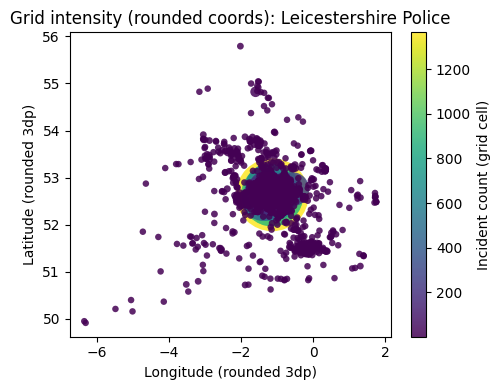

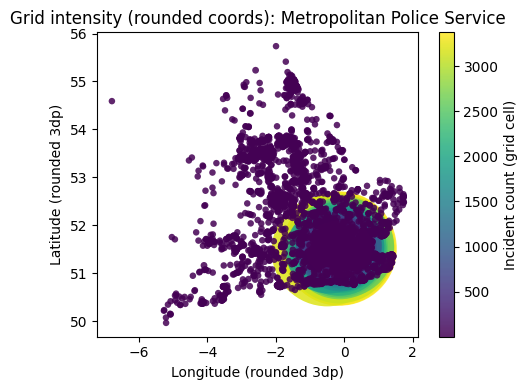

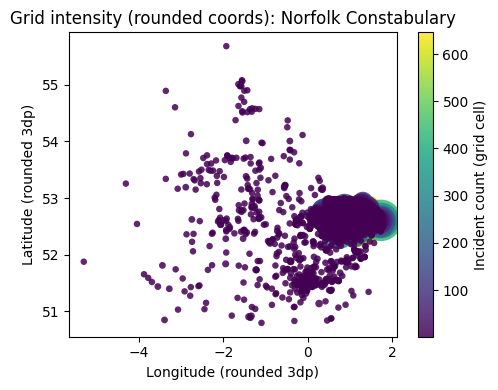

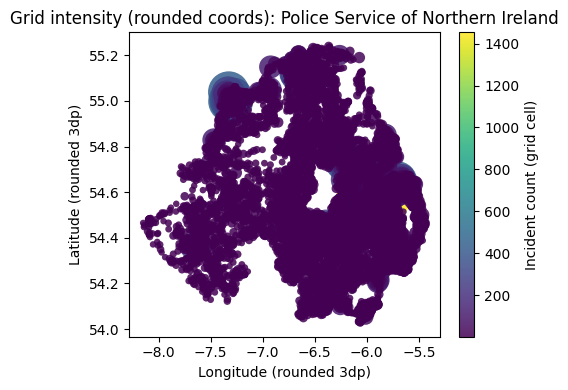

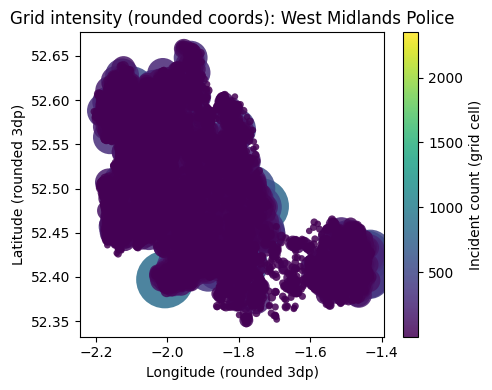

In [21]:
# Plotting: outcome bars and grid intensity

import matplotlib.pyplot as plt

# shares per force, keeps zeros
share = pivot_out.div(pivot_out.sum(axis=1).replace(0, 1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 1.2 * len(share)))
share.plot(kind="barh", stacked=True, ax=ax, width=0.8)

ax.set_title("Outcome mix by force (%)", fontweight='bold')
ax.set_xlabel("% within force", fontweight='bold')
ax.set_ylabel("Force", fontweight='bold')

# Light backgrounds
fig.set_facecolor('#f7f7f7')
ax.set_facecolor('#fcfcfc')

# Clear y labels with simple two‑line wrap
labels = ['\n'.join(f.split()) for f in share.index]
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

# Highlight y‑axis tick labels
ax.tick_params(axis='y', labelsize=10)
for lab in ax.get_yticklabels():
    # lab.set_fontweight('bold')
    lab.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2.0))

# Grid and spines
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend outside below, no overlap
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=5, fontsize=7, frameon=False, handlelength=1.2, handletextpad=0.4)

plt.tight_layout()
plt.subplots_adjust(left=0.22, bottom=0.28)
plt.show()

# ---------- Grid intensity (rounded lat/lon) ----------
pdf_grid = grid_df.toPandas().copy()
forces = list(pd.Series(pdf_grid['force'].unique()).dropna())

for f in forces:
    d = pdf_grid[pdf_grid['force'] == f].copy()
    plt.figure(figsize=(5, 4))
    sc = plt.scatter(d['lon3'], d['lat3'], c=d['ct'], s=20 + 2*d['ct'], cmap='viridis', alpha=0.85, edgecolors='none')
    plt.colorbar(sc, label='Incident count (grid cell)')
    plt.title(f"Grid intensity (rounded coords): {f}")
    plt.xlabel("Longitude (rounded 3dp)")
    plt.ylabel("Latitude (rounded 3dp)")
    plt.tight_layout()
    plt.show()
